In [6]:
# ============================================================
# CELDA 1 · Cargar datos procesados y configurar MLflow
# ============================================================

import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Los 3 modelos que se van a comparar.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# cross_val_score ejecuta la cross-validation y Stratified KFold define cómo dividir los datos
# manteniendo la proporción 73/27 en cada fold
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Cargar los datos procesados del Día 3 ───────────────────
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"X_train: {X_train.shape}  →  {X_train.shape[0]} clientes, {X_train.shape[1]} features")
print(f"X_test:  {X_test.shape}   →  {X_test.shape[0]} clientes, {X_test.shape[1]} features")
print(f"\nDistribución y_train: {np.bincount(y_train.astype(int))}")
print(f"Distribución y_test:  {np.bincount(y_test.astype(int))}")

# ── Configurar MLflow ────────────────────────────────────────
# Crea una carpeta mlruns/ en el proyecto para guardar los experimentos
mlflow.set_tracking_uri('../mlruns')

# Crear o seleccionar el experimento churn_prediction donde se agruparán todos los runs
mlflow.set_experiment('churn_prediction')

print("\n✅ MLflow configurado correctamente")
print("Los experimentos se guardarán en ../mlruns/")

X_train: (5634, 45)  →  5634 clientes, 45 features
X_test:  (1409, 45)   →  1409 clientes, 45 features

Distribución y_train: [4139 1495]
Distribución y_test:  [1035  374]

✅ MLflow configurado correctamente
Los experimentos se guardarán en ../mlruns/


In [7]:
# ============================================================
# CELDA 2 · Función reutilizable de entrenamiento + MLflow
# ============================================================

def entrenar_y_registrar(nombre, modelo, X_train, X_test, y_train, y_test):
    # Recibe el nombre del modelo, el modelo en sí, y los cuatro conjuntos de datos.
    """
    Entrena un modelo, evalúa con cross-validation y test,
    registra todo en MLflow y devuelve las métricas.
    """
    
    with mlflow.start_run(run_name=nombre):
        # El with abre un "run" de MLflow — un contenedor que agrupa todo lo que ocurra 
        # dentro: parámetros, métricas y el modelo. Cuando el bloque with termina, MLflow cierra el run automáticamente 
        # y lo guarda en disco.
        
        # ── 1. Cross-validation (5 folds) ───────────────────
        # Divide X_train en 5 partes iguales
        # Entrena con 4 partes y evalúa con 1 → repite 5 veces
        # Devuelve 5 scores → tomamos la media
        # Stratified → mantiene proporción 73/27 en cada fold
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        cv_scores = cross_val_score(
            modelo, X_train, y_train,
            cv=cv, scoring='roc_auc', n_jobs=-1 # Esto usa todos los núcleos del procesador 
        )                                       # para ejecutar los 5 folds en paralelo, por eso es más rápido que hacerlo manualmente.    
        
        cv_mean = cv_scores.mean()
        cv_std  = cv_scores.std()

        # ROC: Receiver Operating Characteristic
        # AUC: Area Under the Curve
        print(f"\n{'='*50}")
        print(f"Modelo: {nombre}")
        print(f"Cross-validation ROC-AUC (estabilidad del modelo): {cv_mean:.4f} (+/- {cv_std:.4f})")
        
        # ── 2. Entrenar con todos los datos de train ─────────
        # La cross-validation era solo para medir la estabilidad del modelo. 
        # El modelo que guardamos al final usa el 100% de los datos de entrenamiento.
        modelo.fit(X_train, y_train)
        
        # ── 3. Evaluar con datos de test ──────────────────────
        # Dos tipos de predicción (Umbral de decisión)
        y_pred       = modelo.predict(X_test) #devuelve clase final (0 o 1) usando 0.5 por defecto
        y_pred_proba = modelo.predict_proba(X_test)[:, 1] #devuelve probabilidad real entre 0 y 1
        
        roc_auc   = roc_auc_score(y_test, y_pred_proba) #mide calidad del ranking de probabilidades
        f1        = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall    = recall_score(y_test, y_pred)
        
        print(f"Test ROC-AUC:  {roc_auc:.4f}")
        print(f"Test F1:       {f1:.4f}")
        print(f"Test Precision:{precision:.4f}")
        print(f"Test Recall:   {recall:.4f}")
        
        # ── 4. Registrar en MLflow ────────────────────────────
        # Guarda hiperparámetros del modelo
        mlflow.log_params(modelo.get_params())
        
        # Guarda métricas
        mlflow.log_metric('cv_roc_auc_mean', cv_mean)
        mlflow.log_metric('cv_roc_auc_std',  cv_std)
        mlflow.log_metric('test_roc_auc',    roc_auc)
        mlflow.log_metric('test_f1',         f1)
        mlflow.log_metric('test_precision',  precision)
        mlflow.log_metric('test_recall',     recall)
        
        # Serializa y guarda el modelo completo (independientemente de lo que guardaremos con joblib)
        mlflow.sklearn.log_model(modelo, nombre)
        
        return {
            'nombre':    nombre,
            'modelo':    modelo,
            'roc_auc':   roc_auc,
            'f1':        f1,
            'precision': precision,
            'recall':    recall,
            'cv_mean':   cv_mean
        }

print("✅ Función de entrenamiento definida")

✅ Función de entrenamiento definida


In [8]:
# ============================================================
# CELDA 3 · Entrenar los 3 modelos
# ============================================================

# ── Calcular el peso para el desbalanceo ─────────────────────
# scale_pos_weight le dice a XGBoost que los casos positivos (churn)
# pesan más que los negativos → compensa el desbalanceo 73/27
n_neg = np.sum(y_train == 0)   # clientes que no se fueron
n_pos = np.sum(y_train == 1)   # clientes que sí se fueron
scale_pos_weight = n_neg / n_pos # cuando vea un caso positivo (churn) lo trata como si fueran 2.77 casos

print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"(Por cada cliente que se va hay {scale_pos_weight:.1f} que no se van)\n")

resultados = []

# ── MODELO 1: Logistic Regression ────────────────────────────
# El más simple. Aprende una línea que separa los dos grupos.
# Sirve como baseline: si los modelos más complejos no lo superan,
# algo está mal.
lr = LogisticRegression(
    max_iter=1000,       # iteraciones máximas para converger
    class_weight='balanced',  # equivalente a scale_pos_weight
    random_state=42
)
resultados.append(
    entrenar_y_registrar('LogisticRegression', lr, X_train, X_test, y_train, y_test)
)

# ── MODELO 2: Random Forest ───────────────────────────────────
# Entrena 200 árboles de decisión independientes y hace votación.
# Más robusto que un árbol solo, menos propenso a overfitting.
rf = RandomForestClassifier(
    n_estimators=200,    # número de árboles
    max_depth=10,        # profundidad máxima de cada árbol
    class_weight='balanced',
    random_state=42,
    n_jobs=-1            # usa todos los núcleos del procesador
)
resultados.append(
    entrenar_y_registrar('RandomForest', rf, X_train, X_test, y_train, y_test)
)

# ── MODELO 3: XGBoost ─────────────────────────────────────────
# El modelo más potente de los tres para datos tabulares.
# Construye árboles de forma secuencial: cada árbol corrige
# los errores del anterior (boosting).
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,   # desbalanceo
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
resultados.append(
    entrenar_y_registrar('XGBoost', xgb, X_train, X_test, y_train, y_test)
)

scale_pos_weight: 2.77
(Por cada cliente que se va hay 2.8 que no se van)


Modelo: LogisticRegression
Cross-validation ROC-AUC (estabilidad del modelo): 0.8448 (+/- 0.0122)
Test ROC-AUC:  0.8385
Test F1:       0.6116
Test Precision:0.5061
Test Recall:   0.7727

Modelo: RandomForest
Cross-validation ROC-AUC (estabilidad del modelo): 0.8392 (+/- 0.0078)
Test ROC-AUC:  0.8348
Test F1:       0.6068
Test Precision:0.5383
Test Recall:   0.6952

Modelo: XGBoost
Cross-validation ROC-AUC (estabilidad del modelo): 0.8361 (+/- 0.0116)
Test ROC-AUC:  0.8294
Test F1:       0.6091
Test Precision:0.5198
Test Recall:   0.7353


In [9]:
# ============================================================
# CELDA 4 · Comparar modelos y guardar el ganador
# ============================================================

# ── Tabla comparativa ─────────────────────────────────────────
print("\n=== COMPARATIVA FINAL DE MODELOS ===\n")
print(f"{'Modelo':<22} {'ROC-AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8} {'CV-AUC':>8}")
print("-" * 70)
for r in resultados:
    print(f"{r['nombre']:<22} {r['roc_auc']:>8.4f} {r['f1']:>8.4f} "
          f"{r['precision']:>10.4f} {r['recall']:>8.4f} {r['cv_mean']:>8.4f}")

# ── Elegir el mejor por ROC-AUC ───────────────────────────────
mejor = max(resultados, key=lambda x: x['roc_auc'])
print(f"\n🏆 Mejor modelo: {mejor['nombre']} con ROC-AUC = {mejor['roc_auc']:.4f}")

# ── Guardar el mejor modelo ───────────────────────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(mejor['modelo'], '../models/best_model.pkl')
print(f"✅ Mejor modelo guardado en models/best_model.pkl")


=== COMPARATIVA FINAL DE MODELOS ===

Modelo                  ROC-AUC       F1  Precision   Recall   CV-AUC
----------------------------------------------------------------------
LogisticRegression       0.8385   0.6116     0.5061   0.7727   0.8448
RandomForest             0.8348   0.6068     0.5383   0.6952   0.8392
XGBoost                  0.8294   0.6091     0.5198   0.7353   0.8361

🏆 Mejor modelo: LogisticRegression con ROC-AUC = 0.8385
✅ Mejor modelo guardado en models/best_model.pkl


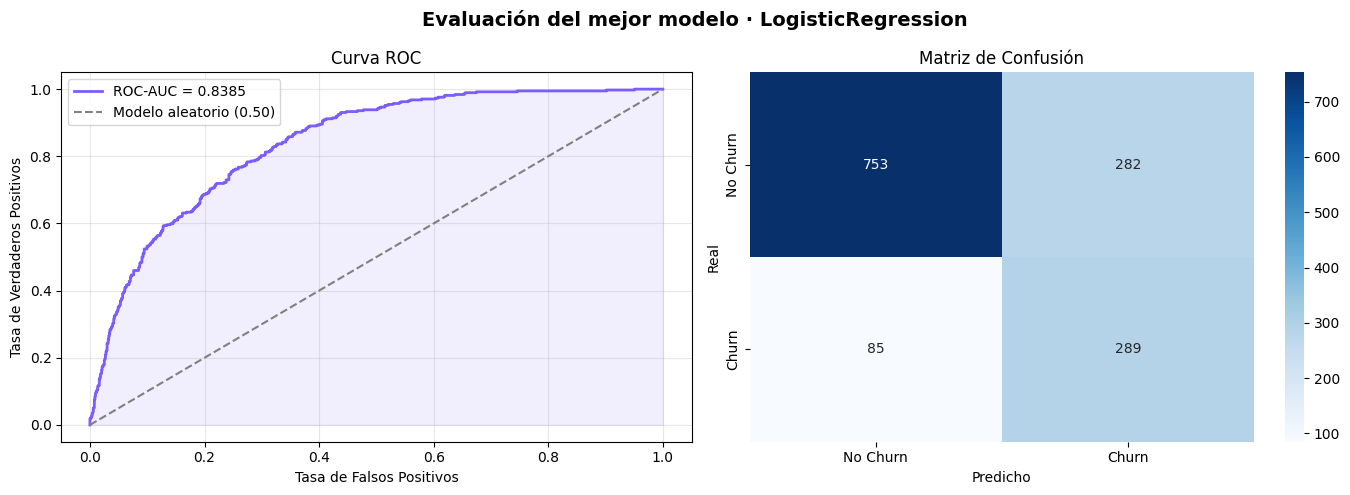


=== INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN ===
Verdaderos Negativos (TN): 753  → predijo No Churn y era correcto
Falsos Positivos     (FP): 282  → predijo Churn pero no se fue
Falsos Negativos     (FN): 85  → predijo No Churn pero sí se fue ⚠️
Verdaderos Positivos (TP): 289  → predijo Churn y era correcto

⚠️ Los Falsos Negativos son el error más costoso:
   Son clientes que SÍ se fueron y el modelo no detectó

✅ Gráfica guardada en reports/figures/model_evaluation.png


In [10]:
# ============================================================
# CELDA 5 · Visualizaciones del mejor modelo
# ============================================================

modelo_ganador = mejor['modelo']
y_pred         = modelo_ganador.predict(X_test)
y_pred_proba   = modelo_ganador.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluación del mejor modelo · {mejor["nombre"]}',
             fontsize=14, fontweight='bold')

# ── Gráfica 1: Curva ROC ──────────────────────────────────────
# Representa el modelo con todos los umbrales posibles entre 0 y 1.
# Cada punto de la curva responde a la pregunta: "Si digo que es Churn
# cuando la probabilidad supera x%, ¿cuántos detecto correctamente y 
# cuántas alarmas genero?
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#7c5cfc', lw=2,
             label=f'ROC-AUC = {mejor["roc_auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Modelo aleatorio (0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#7c5cfc')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Gráfica 2: Matriz de confusión ───────────────────────────
# Muestra exactamente cuántos clientes clasificó bien y mal
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].set_title('Matriz de Confusión')

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Añadir interpretación debajo de la matriz
tn, fp, fn, tp = cm.ravel()
print(f"\n=== INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN ===")
print(f"Verdaderos Negativos (TN): {tn}  → predijo No Churn y era correcto")
print(f"Falsos Positivos     (FP): {fp}  → predijo Churn pero no se fue")
print(f"Falsos Negativos     (FN): {fn}  → predijo No Churn pero sí se fue ⚠️")
print(f"Verdaderos Positivos (TP): {tp}  → predijo Churn y era correcto")
print(f"\n⚠️ Los Falsos Negativos son el error más costoso:")
print(f"   Son clientes que SÍ se fueron y el modelo no detectó")
print("\n✅ Gráfica guardada en reports/figures/model_evaluation.png")

*Comentarios sobre la Curva ROC:*  
*La línea diagonal del centro es un modelo que acierta igual que lanzar una moneda. Cualquier curva por encima es útil y cuanto más se acerque hacia arriba a la izquierda mejor.   
El eje Y representa: de todos los clientes que sí se fueron, ¿qué porcentaje detectas?
El eje X representa: de todos los clientes que no se fueron, ¿a cuántos molestaste diciéndoles que sí?
Si el área bajo la curva es 0.5 el modelo es inútil porque funciona como una moneda. Se considera bueno a partir de 0.8, que es nuestro caso.*

# CONCLUSIONES # 

**Entrenamiento con MLflow**:

| Modelo | ROC-AUC | F1 | Precision | Recall | CV-AUC |
|---|---|---|---|---|---|
| **LogisticRegression** | **0.8385** | **0.6116** | 0.5061 | **0.7727** | **0.8448** |
| RandomForest | 0.8348 | 0.6068 | **0.5383** | 0.6952 | 0.8392 |
| XGBoost | 0.8294 | 0.6091 | 0.5198 | 0.7353 | 0.8361 |

**Por qué gana Logistic Regression**:  
El dataset Telco tiene relaciones predominantemente lineales: variables como tenure, tipo de contrato y cargo mensual predicen el churn de forma directa y predecible. XGBoost y RandomForest buscan patrones no lineales que en este dataset no existen en cantidad suficiente para compensar su mayor complejidad.  
Los scores de Cross-Validation (CV-AUC) y Test (ROC-AUC) son muy similares en los tres modelos, lo que confirma que no hay overfitting.  
El ROC-AUC de 0.8385 supera el umbral mínimo de 0.80 que se usará en los tests de CI/CD.  
Debido a que el valor de la Precisión es mediocre podríamos plantearnos añadir más modelos, pero los 3 escogidos son especialmente potentes para datos tabulares. Además, hemos priorizado la generación de más falsas alarmas (class_weight='balanced') por la tipología del problema a resolver. Sí que se puede ajustar el umbral de decisión y ajustar los hiperparámetros del modelo, lo que se planteará más adelante.

**Análisis de la Matriz de Confusión**:  

| Categoría                 | Cantidad | Interpretación                                        |
|:--------------------------|:---------|:------------------------------------------------------|
| Verdaderos Positivos (TP) | 289      | Clientes en riesgo detectados correctamente ✅         |
| Verdaderos Negativos (TN) | 753      | Clientes sin riesgo identificados correctamente ✅     |
| Falsos Negativos (FN)     | 85       | Clientes que se fueron y **no se detectaron** ⚠️      |
| Falsos Positivos (FP)     | 282      | Falsas alarmas: predijo churn pero no se fueron ℹ️    |  

**Interpretación de negocio**:  
De los 374 clientes que realmente se fueron, el modelo detectó 289 a tiempo para hacer una oferta de retención.
El ratio FP/TP es aproximadamente 1:1, lo que explica la Precision baja de 0.50.
Esto es aceptable en telecomunicaciones: si el coste de una oferta de retención es menor que el coste de perder al cliente, actuar sobre los 288 falsos positivos sigue siendo rentable.


**Archivos generados**:  
models/best_model.pkl — LogisticRegression serializado  
reports/figures/model_evaluation.png — Curva ROC + Matriz de confusión  
mlruns/ — Experimentos registrados en MLflow  
